# Predictive Paradox - Power Demand Forecasting

Predicting next hour electricity demand for Bangladesh's power grid using historical data, weather and economic indicators.

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
import warnings
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
warnings.filterwarnings('ignore')

## Loading the Data

In [2]:
pgcb = pd.read_excel('/kaggle/input/datasets/ayush20081303/data-predictive-paradox/PGCB_date_power_demand.xlsx')
pgcb.head()

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
0,2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
1,2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2,2015-04-19 19:00:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN
3,2015-04-19 18:30:00,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak
4,2015-04-19 18:00:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN


In [3]:
pgcb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92650 entries, 0 to 92649
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   datetime              92650 non-null  datetime64[ns]
 1   generation_mw         92650 non-null  float64       
 2   demand_mw             92650 non-null  int64         
 3   load_shedding         92650 non-null  int64         
 4   gas                   92650 non-null  int64         
 5   liquid_fuel           92650 non-null  int64         
 6   coal                  92650 non-null  int64         
 7   hydro                 92650 non-null  int64         
 8   solar                 70517 non-null  float64       
 9   wind                  18676 non-null  float64       
 10  india_bheramara_hvdc  92650 non-null  int64         
 11  india_tripura         92650 non-null  int64         
 12  india_adani           7338 non-null   float64       
 13  nepal           

In [4]:
pgcb.describe()

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal
count,92650,9.265000e+04,92650.000000,92650.000000,92650.000000,9.265000e+04,92650.000000,92650.000000,70517.000000,18676.000000,92650.000000,92650.000000,7338.000000,5351.000000
mean,2020-05-17 03:52:07.609282304,9.429376e+03,8819.646044,81.470405,5120.782914,2.038257e+03,974.349768,96.899007,46.224101,9.233133,663.169261,93.616773,881.196375,0.546814
min,2015-04-19 00:00:00,7.300000e+01,6.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2017-10-31 06:15:00,6.814775e+03,6812.250000,0.000000,4419.000000,7.200000e+02,159.000000,40.000000,0.000000,0.000000,465.000000,70.000000,702.000000,0.000000
50%,2020-05-21 15:30:00,8.412000e+03,8422.000000,0.000000,5022.000000,1.535000e+03,401.000000,79.000000,0.000000,4.000000,705.000000,97.000000,822.000000,0.000000
75%,2022-12-03 18:22:30,1.055600e+04,10633.000000,0.000000,5812.000000,2.462000e+03,1220.000000,150.000000,25.000000,13.000000,910.000000,126.000000,1050.750000,0.000000
max,2025-06-17 12:00:00,6.452650e+07,156050.000000,65359.000000,74818.000000,2.922290e+07,31687.000000,5623.000000,2998.000000,922.000000,76292.000000,1565.000000,12665.000000,38.000000
std,NaN,2.119759e+05,2772.150108,442.757182,1138.938147,9.608105e+04,1226.515481,71.442697,106.410644,16.272517,349.609395,47.483221,369.905673,4.525897


In [5]:
weather = pd.read_excel('/kaggle/input/datasets/ayush20081303/data-predictive-paradox/weather_data.xlsx',header=None)
weather = weather.iloc[3:]
weather.columns = weather.iloc[0]
weather = weather.iloc[1:]
weather.columns = ['datetime', 'temperature', 'humidity', 'app_temp',
                   'precipitation', 'dew_point', 'soil_temp', 'wind_dir', 'cloud_cover', 'sunshine']
weather.head()

,datetime,temperature,humidity,app_temp,precipitation,dew_point,soil_temp,wind_dir,cloud_cover,sunshine
4,2014-01-01 00:00:00,13.9,89,13.3,0,12.1,16.4,313,0,0
5,2014-01-01 01:00:00,13.6,91,13.2,0,12.1,16,317,0,0
6,2014-01-01 02:00:00,13.3,91,12.8,0,11.9,15.7,317,0,0
7,2014-01-01 03:00:00,13,92,12.5,0,11.8,15.4,319,0,0
8,2014-01-01 04:00:00,12.7,93,12.2,0,11.6,15.2,322,0,0


In [6]:
economic = pd.read_csv('/kaggle/input/datasets/ayush20081303/data-predictive-paradox/economic_full_1.csv')
economic.head()

,Country Name,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,X,"Intentional homicides, male (per 100,000 male)",VC.IHR.PSRC.MA.P5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,X,Battle-related deaths (number of people),VC.BTL.DETH,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,41.000000,47.000000,NaN,NaN,2.000000,NaN,2.000000,NaN,2.000000,NaN
2,X,Voice and Accountability: Percentile Rank,VA.PER.RNK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,30.541872,30.049261,27.184465,26.570047,26.570047,28.019323,28.019323,27.450981,NaN,NaN
3,X,Transport services (% of commercial service ex...,TX.VAL.TRAN.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,20.820301,21.484188,22.048898,19.559759,22.257010,27.162699,25.520411,17.176637,23.495141,NaN
4,X,"Computer, communications and other services (%...",TX.VAL.OTHR.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,64.068305,57.202109,62.313903,63.578283,67.395621,64.565856,63.537174,67.817057,65.566600,NaN


## EDA

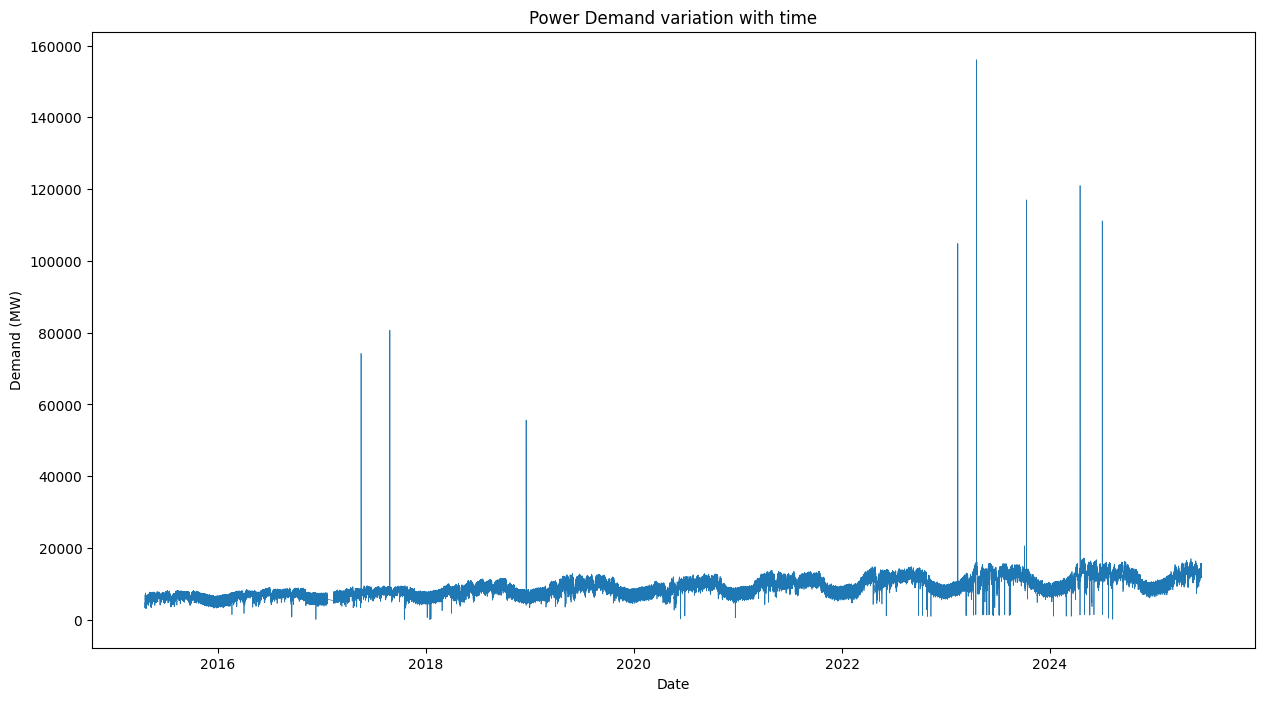

In [7]:
pgcb['datetime'] = pd.to_datetime(pgcb['datetime'])
pgcb = pgcb.sort_values('datetime').reset_index(drop=True)

plt.figure(figsize=(15,8))
plt.plot(pgcb['datetime'], pgcb['demand_mw'], linewidth=0.5)
plt.title('Power Demand variation with time')
plt.xlabel('Date')
plt.ylabel('Demand (MW)')
plt.show()

In [8]:
print("Missing data - pgcb:")
print(pgcb.isnull().sum())

Missing data - pgcb:
datetime                    0
generation_mw               0
demand_mw                   0
load_shedding               0
gas                         0
liquid_fuel                 0
coal                        0
hydro                       0
solar                   22133
wind                    73974
india_bheramara_hvdc        0
india_tripura               0
india_adani             85312
nepal                   87299
remarks                 86257
dtype: int64


In [9]:
print("Duplicate rows:", pgcb.duplicated('datetime').sum())

Duplicate rows: 432


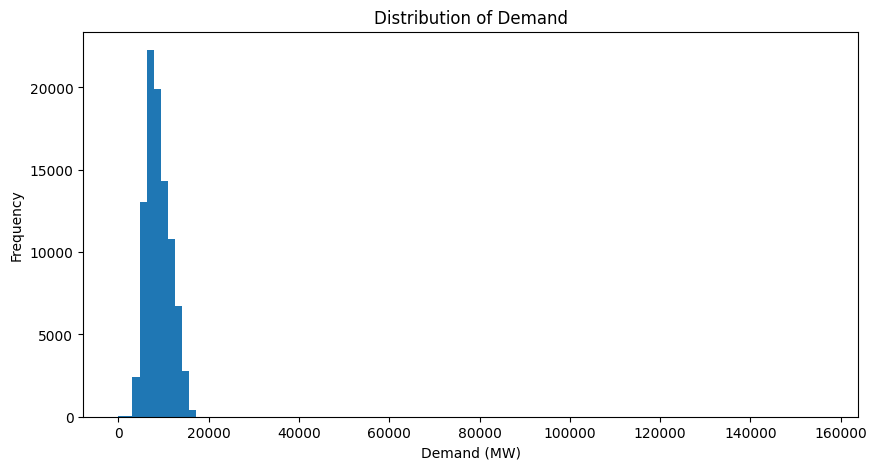

In [10]:
 plt.figure(figsize=(10,5))

plt.hist(pgcb['demand_mw'],bins=100)

plt.title('Distribution of Demand')
plt.xlabel('Demand (MW)')
plt.ylabel('Frequency')

plt.show()

#notice the rather skewed data

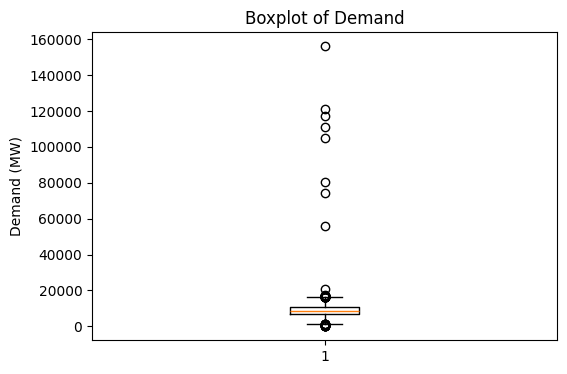

In [11]:
plt.figure(figsize=(6,4))
plt.boxplot(pgcb['demand_mw'])

plt.title("Boxplot of Demand")
plt.ylabel("Demand (MW)")

plt.show()

#fairly lesser values out of box -> IQR removal is safe

In [12]:
pgcb['demand_mw'].skew() # data is right skewed

np.float64(4.71382218359586)

In [13]:
cols = ['temperature', 'humidity', 'app_temp', 'precipitation']
print("Missing data - weather:")
print(weather[cols].isnull().sum())
print("\n")
for col in cols:
    print(f"{col} -> min = {weather[col].min()}, max = {weather[col].max()}")
print("\n")

print("Duplicate rows:", weather.duplicated('datetime').sum())

Missing data - weather:
temperature      0
humidity         0
app_temp         0
precipitation    0
dtype: int64


temperature -> min = 8.4, max = 40.8
humidity -> min = 15, max = 100
app_temp -> min = 6.6, max = 45.6
precipitation -> min = 0, max = 43.8


Duplicate rows: 0


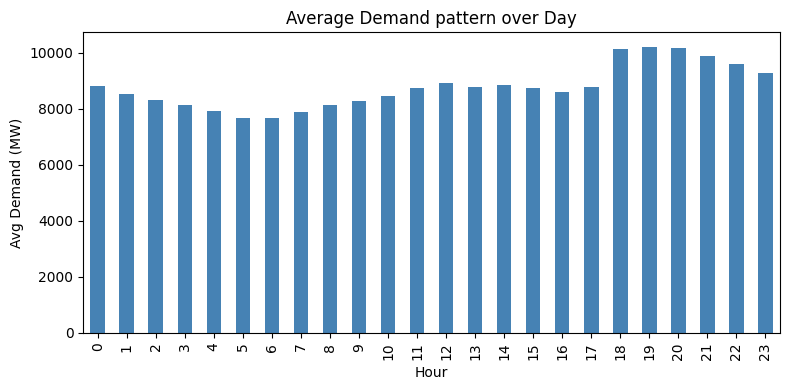

In [14]:
#hourly average pattern -> prediction of next hour demand
pgcb['hour'] = pgcb['datetime'].dt.hour
hourly_avg = pgcb.groupby('hour')['demand_mw'].mean()

plt.figure(figsize=(8,4))
hourly_avg.plot(kind='bar', color='steelblue')
plt.title('Average Demand pattern over Day')
plt.xlabel('Hour')
plt.ylabel('Avg Demand (MW)')
plt.tight_layout()
plt.show()

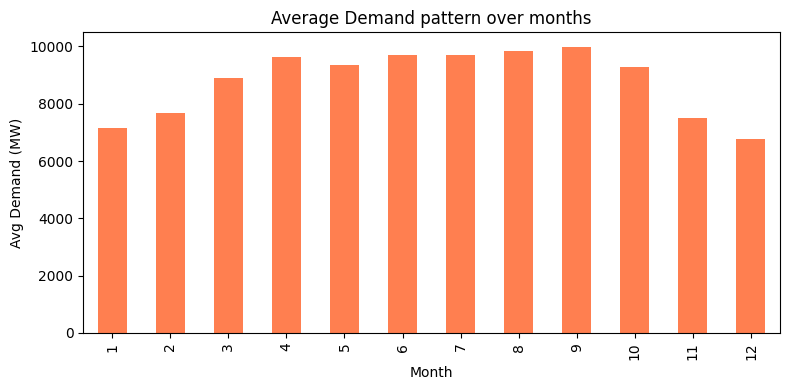

In [15]:
#month average pattern -> seasonal variations
pgcb['month'] = pgcb['datetime'].dt.month
monthly_avg = pgcb.groupby('month')['demand_mw'].mean()

plt.figure(figsize=(8,4))
monthly_avg.plot(kind='bar', color='coral')
plt.title('Average Demand pattern over months')
plt.xlabel('Month')
plt.ylabel('Avg Demand (MW)')
plt.tight_layout()
plt.show()

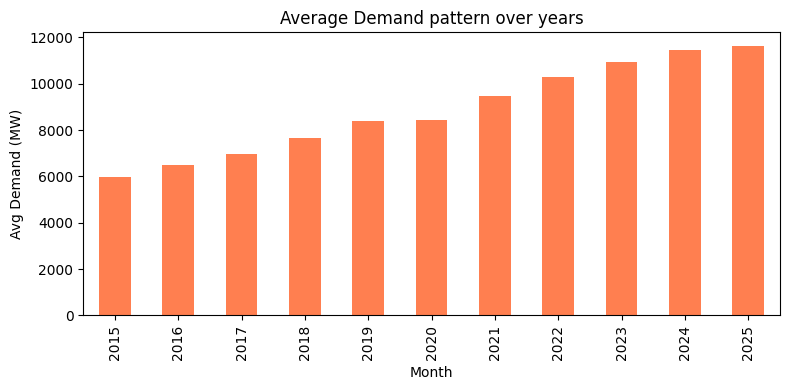

In [16]:
#year average pattern -> economic factors 
pgcb['year'] = pgcb['datetime'].dt.year
yearly_avg = pgcb.groupby('year')['demand_mw'].mean()

plt.figure(figsize=(8,4))
yearly_avg.plot(kind='bar', color='coral')
plt.title('Average Demand pattern over years')
plt.xlabel('Month')
plt.ylabel('Avg Demand (MW)')
plt.tight_layout()
plt.show()

## Data Preprocessing

### Removing Outliers (IQR Method)

In [17]:
Q1 = pgcb['demand_mw'].quantile(0.25)
Q3 = pgcb['demand_mw'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower bound: {lower_bound:.0f} MW")
print(f"Upper bound: {upper_bound:.0f} MW")

pgcb = pgcb[(pgcb['demand_mw'] >= lower_bound) & (pgcb['demand_mw'] <= upper_bound)]
pgcb = pgcb.drop_duplicates('datetime').reset_index(drop=True)

Lower bound: 1081 MW
Upper bound: 16364 MW


In [18]:
# Managing half hours


def smooth_half_hourly(df):
    df = df.sort_values('datetime').reset_index(drop=True)
    is_half = df['datetime'].dt.minute == 30
    
    hourly_df = df[df['datetime'].dt.minute == 0].set_index('datetime')['demand_mw']

    def blend(row):
        if not (row['datetime'].minute == 30):
            return row['demand_mw']
      
        recent_hour = row['datetime'].replace(minute=0, second=0, microsecond=0)
        if recent_hour in hourly_df.index:
            return 0.5 * hourly_df[recent_hour] + 0.5 * row['demand_mw']
        return row['demand_mw']

    df['demand_mw'] = df.apply(blend, axis=1)
    return df


In [19]:
#Missing timestamps
full_range = pd.date_range(
    start=pgcb['datetime'].min(),
    end=pgcb['datetime'].max(),
    freq='H'
)

pgcb = pgcb.set_index('datetime').reindex(full_range)
pgcb.index.name = 'datetime'
pgcb = pgcb.reset_index()

print(f"Missing demand rows: {pgcb['demand_mw'].isna().sum()}")


Missing demand rows: 1137


### Preparing Weather Data

In [20]:
weather['datetime'] = pd.to_datetime(weather['datetime'])
for col in weather.columns[1:]:
    weather[col] = pd.to_numeric(weather[col], errors='coerce')

weather = weather.drop_duplicates('datetime').reset_index(drop=True)

print(weather.shape)
weather.head(3)

(107304, 10)


,datetime,temperature,humidity,app_temp,precipitation,dew_point,soil_temp,wind_dir,cloud_cover,sunshine
0,2014-01-01 00:00:00,13.9,89,13.3,0.0,12.1,16.4,313,0,0.0
1,2014-01-01 01:00:00,13.6,91,13.2,0.0,12.1,16.0,317,0,0.0
2,2014-01-01 02:00:00,13.3,91,12.8,0.0,11.9,15.7,317,0,0.0


### Preparing Economic Data

In [21]:
# selecting the related fields
selected = [
    'Population, total',
    'Electric power consumption (kWh per capita)',
    'Access to electricity, urban (% of urban population)',
    'GDP per capita (current US$)'
]

# filter
econ_sub = economic[economic['Indicator Name'].isin(selected)].copy()

print("Found indicators:")
print(econ_sub['Indicator Name'].unique())

# pick year columns
year_cols = [c for c in econ_sub.columns if c.isdigit()]

# melt
econ_long = econ_sub.melt(
    id_vars=['Indicator Name'],
    value_vars=year_cols,
    var_name='year',
    value_name='value'
)

econ_long['year'] = econ_long['year'].astype(int)

# pivot
econ_wide = econ_long.pivot_table(
    index='year',
    columns='Indicator Name',
    values='value',
    aggfunc='first'
).reset_index()

#demand_mw has data after 2015 only
econ_wide = econ_wide[econ_wide['year'] >= 2015]

#renaming for convinience
rename_map = {
    'Population, total': 'econ_pop_total',
    'Electric power consumption (kWh per capita)': 'econ_power_per_capita',
    'Access to electricity, urban (% of urban population)': 'econ_elec_access_urban',
    'GDP per capita (current US$)':'econ_gdp'
}

econ_wide = econ_wide.rename(columns=rename_map)
print("Related factors after renaming : ")
print(econ_wide.columns)

econ_wide.head()



all_years = pd.DataFrame({'year': range(econ_wide['year'].min(), 2026)})
econ_wide = all_years.merge(econ_wide, on='year', how='left').ffill()

print("\nEconomic data after forward fill:")
econ_wide.tail(5)



Found indicators:
['Population, total' 'GDP per capita (current US$)'
 'Electric power consumption (kWh per capita)'
 'Access to electricity, urban (% of urban population)']
Related factors after renaming : 
Index(['year', 'econ_elec_access_urban', 'econ_power_per_capita', 'econ_gdp',
       'econ_pop_total'],
      dtype='object', name='Indicator Name')

Economic data after forward fill:


,year,econ_elec_access_urban,econ_power_per_capita,econ_gdp,econ_pop_total
6,2021,99.7,574.118203,2482.849178,167658854.0
7,2022,100.0,602.674747,2716.485928,169384897.0
8,2023,99.5,602.674747,2551.017738,171466990.0
9,2024,99.5,602.674747,2593.416117,173562364.0
10,2025,99.5,602.674747,2593.416117,173562364.0


### Merging Datasets

In [22]:
df = pgcb[['datetime', 'demand_mw']].merge(
    weather[['datetime', 'temperature', 'humidity', 'app_temp',
                   'precipitation']],
    on='datetime',
    how='left'
)

df['year'] = df['datetime'].dt.year
df = df.merge(econ_wide, on='year', how='left')
df = df.sort_values('datetime').reset_index(drop=True)

print("Shape after merge:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

Shape after merge: (89101, 11)

Missing values:
datetime                     0
demand_mw                 1137
temperature                  0
humidity                     0
app_temp                     0
precipitation                0
year                         0
econ_elec_access_urban       0
econ_power_per_capita        0
econ_gdp                     0
econ_pop_total               0
dtype: int64


In [23]:
print("Shape after merge:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

Shape after merge: (89101, 11)

Missing values:
datetime                     0
demand_mw                 1137
temperature                  0
humidity                     0
app_temp                     0
precipitation                0
year                         0
econ_elec_access_urban       0
econ_power_per_capita        0
econ_gdp                     0
econ_pop_total               0
dtype: int64


## Feature Engineering

In [24]:
df['hour'] = df['datetime'].dt.hour
df['weekday'] = df['datetime'].dt.dayofweek
df['month'] = df['datetime'].dt.month
df['weekend'] = (df['weekday'] >= 5).astype(int)

In [25]:
# lag features - previous demand values
df['lag_24h'] = df['demand_mw'].shift(24)    # demand 24 hours ago
df['lag_48h'] = df['demand_mw'].shift(48)    # demand 48 hours ago
df['lag_168h'] = df['demand_mw'].shift(168)  # demand 1 week ago

In [26]:
# rolling mean
df['rolling_mean_24h'] = df['demand_mw'].shift(1).rolling(window=24).mean()


In [27]:
lag_cols = ['lag_24h', 'lag_48h', 'lag_168h', 'rolling_mean_24h']
for col in lag_cols:
    df[col] = df[col].ffill(limit=3)

In [28]:
# target = next hour demand
df['target'] = df['demand_mw'].shift(-1)

#drop nans
df = df.dropna(subset=[
    'lag_24h','lag_48h','lag_168h','rolling_mean_24h','target'
]).reset_index(drop=True)

print("Final dataset shape:", df.shape)

df.head()


Final dataset shape: (81924, 20)


,datetime,demand_mw,temperature,humidity,app_temp,precipitation,year,econ_elec_access_urban,econ_power_per_capita,econ_gdp,econ_pop_total,hour,weekday,month,weekend,lag_24h,lag_48h,lag_168h,rolling_mean_24h,target
0,2015-04-27 21:00:00,5784.0,25.2,88,29.7,0.0,2015,93.6,348.932681,1224.386477,159383179.0,21,0,4,0,6363.0,6167.0,6702.0,5394.916667,5499.0
1,2015-04-27 22:00:00,5499.0,24.4,91,28.8,0.0,2015,93.6,348.932681,1224.386477,159383179.0,22,0,4,0,5995.0,6167.0,6702.0,5370.791667,5246.0
2,2015-04-27 23:00:00,5246.0,24.1,93,28.5,0.0,2015,93.6,348.932681,1224.386477,159383179.0,23,0,4,0,5587.0,6167.0,6702.0,5350.125000,4898.0
3,2015-04-28 21:00:00,6169.0,25.4,87,30.0,0.0,2015,93.6,348.932681,1224.386477,159383179.0,21,1,4,0,5784.0,6363.0,6712.0,5172.333333,5764.0
4,2015-04-28 22:00:00,5764.0,25.1,88,29.5,0.0,2015,93.6,348.932681,1224.386477,159383179.0,22,1,4,0,5499.0,5995.0,6551.0,5188.375000,5519.0


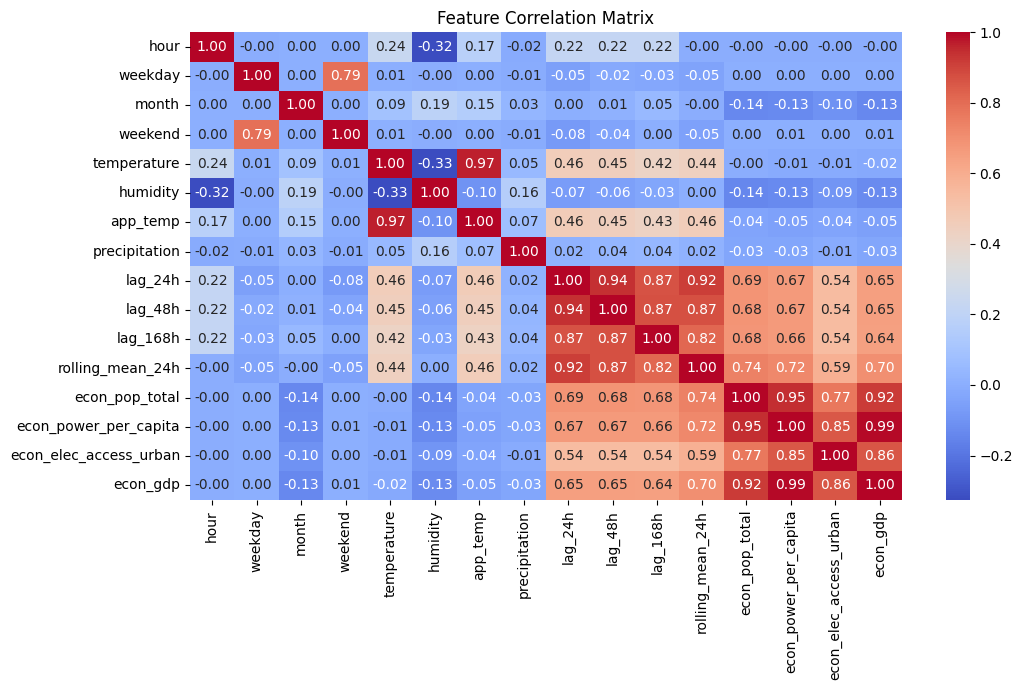

In [29]:
# correlation heatmap
econ_cols = [
    'econ_pop_total',
    'econ_power_per_capita',
    'econ_elec_access_urban',
    'econ_gdp'
    
]

feature_cols = [
    'hour','weekday','month','weekend',
    'temperature','humidity','app_temp',
    'precipitation',
    'lag_24h','lag_48h','lag_168h','rolling_mean_24h'
] + econ_cols

plt.figure(figsize=(11,7))
sns.heatmap(df[feature_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## Model Training

### Train Test Split

Using data before 2024 for training and 2024 as test set (chronological split to avoid data leakage).

In [30]:
train = df[df['datetime'].dt.year < 2024].copy()
test  = df[df['datetime'].dt.year == 2024].copy()

print("Training samples:", len(train))
print("Testing samples:", len(test))

Training samples: 69979
Testing samples: 8072


In [31]:
exclude = ['datetime','target']
features = [col for col in df.columns if col not in exclude]

X_train = train[features]
y_train = train['target']

X_test = test[features]
y_test = test['target']

### LightGBM Regressor

In [32]:
model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

model.fit(X_train, y_train)
print("Training done")

Training done


## Evaluation

In [33]:
predictions = model.predict(X_test)

mape = mean_absolute_percentage_error(y_test, predictions) * 100
mae  = mean_absolute_error(y_test, predictions)
print(f"MAPE: {mape:.2f}%")
print(f"MAE:  {mae:.2f} MW")

MAPE: 2.77%
MAE:  245.15 MW


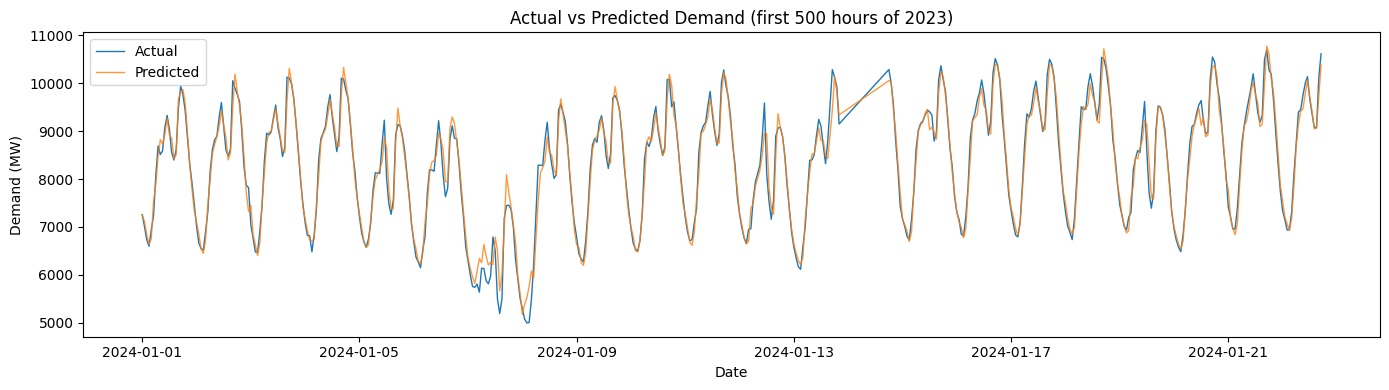

In [34]:
plt.figure(figsize=(14,4))
plt.plot(test['datetime'].values[:500], y_test.values[:500], label='Actual', linewidth=1)
plt.plot(test['datetime'].values[:500], predictions[:500], label='Predicted', linewidth=1, alpha=0.8)
plt.title('Actual vs Predicted Demand (first 500 hours of 2023)')
plt.xlabel('Date')
plt.ylabel('Demand (MW)')
plt.legend()
plt.tight_layout()
plt.show()

## Feature Importance

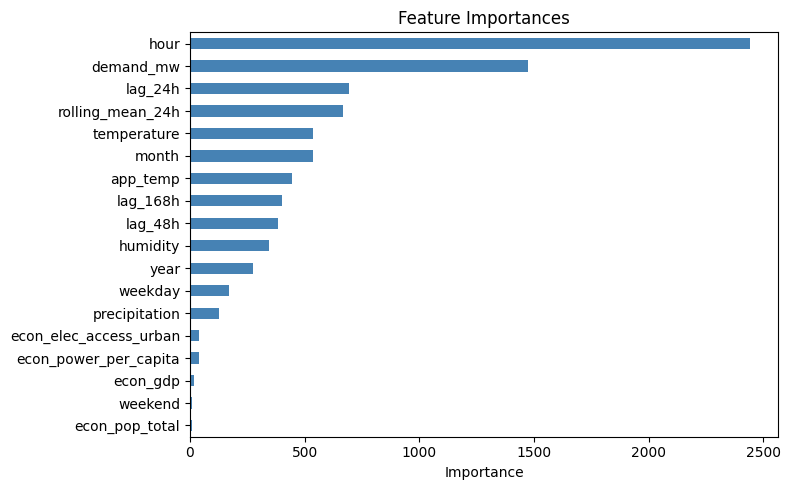

In [35]:
fi = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(8,5))
fi.plot(kind='barh', color='steelblue')
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## Summary

**Model:** LightBGM Regressor

**Test MAPE:** 2.77%  

**Test Set:** All of 2024

**Training Set:** All years from 2015-2023
